# Active Return Attribution — Demo Walkthrough

Two complementary explanations of the portfolio's active return vs. its benchmark:

1. **Brinson-Fachler** (holdings-based): allocation / selection / interaction by GICS sector, Carino-linked across time.
2. **Factor attribution** (returns-based): CAPM / FF3 / FF5 / Carhart, with hand-rolled OLS + Newey-West standard errors.

All data is real (yfinance + Ken French). All math is implemented from scratch in `src/attribution`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from attribution.pipeline import load_bundle
from attribution.brinson import run_brinson, reconciliation_report
from attribution.factor_model import regress, regress_all_models, rolling_betas, build_excess_return

bundle = load_bundle()
print('Sample:', bundle.active_return.index.min().date(), '->', bundle.active_return.index.max().date(),
      f'({len(bundle.active_return)} months)')
print('Reconstructed-vs-SPY annualized tracking error: '
      f"{bundle.tracking['diff'].std()*(12**0.5)*100:.2f}%")

16:39:07 | INFO    | attribution.config | Loaded portfolio 'Concentrated US Large-Cap Growth Tilt': 30 holdings across 11 sectors, rebalance=Q


16:39:07 | INFO    | attribution.config | Loaded benchmark: 11 sectors, snapshot 2025-06-30 (weights normalized from 99.0%)


16:39:07 | INFO    | attribution.data.prices | Downloading daily prices for 42 tickers from yfinance...


16:39:08 | INFO    | attribution.data.prices | Cached prices -> /Users/rohan/Desktop/Claude Code/active-return-attribution/data/prices.parquet (2765 rows)


16:39:08 | INFO    | attribution.data.factors | Fetching Ken French factors via pandas-datareader...


16:39:09 | INFO    | attribution.data.factors | Cached factors -> /Users/rohan/Desktop/Claude Code/active-return-attribution/data/factors.parquet (132 months)


16:39:09 | INFO    | attribution.pipeline | Analysis sample ends 2025-12-31 (prices ∩ factors).


16:39:09 | INFO    | attribution.portfolio | Simulated portfolio: 131 months (2015-02-28 to 2025-12-31), 11 sectors.


16:39:09 | INFO    | attribution.data.benchmark | Reconstructed-vs-market tracking: mean abs monthly diff = 0.3239%, annualized tracking error = 1.41%


Sample: 2015-02-28 -> 2025-12-31 (131 months)
Reconstructed-vs-SPY annualized tracking error: 1.41%


## Module A — Brinson-Fachler attribution

In [2]:
brinson = run_brinson(bundle.panel, bundle.bench_sector_returns, bundle.benchmark_cfg)
recon = reconciliation_report(brinson)
print('Max single-period reconciliation error:', f"{recon['max_single_period_error']:.2e}")
print('Carino linked reconciliation error:    ', f"{recon['linked_reconciliation_error']:.2e}")
(brinson.linked_by_sector.sort_values('total', ascending=False) * 100).round(2)

16:39:09 | INFO    | attribution.brinson | Brinson: 90 months (2018-07-31 to 2025-12-31). Cumulative active = 208.98% (alloc -19.05%, sel 237.07%, inter -9.04%).


Max single-period reconciliation error: 4.16e-17
Carino linked reconciliation error:     3.55e-15


,allocation,selection,interaction,total
Information Technology,-10.11,122.78,-24.10,88.58
Health Care,-0.98,34.47,6.17,39.66
Communication Services,-0.50,25.42,7.45,32.37
Financials,3.27,26.49,-9.82,19.95
Consumer Staples,-4.85,11.96,6.85,13.96
Materials,-1.72,5.43,3.05,6.75
Industrials,1.22,4.26,-1.20,4.28
Energy,0.57,1.49,0.60,2.66
Utilities,0.31,1.90,-0.37,1.84
Consumer Discretionary,-0.79,0.96,-0.26,-0.10


In [3]:
print('Linked totals (%):')
(brinson.linked_totals * 100).round(2)

Linked totals (%):


allocation     -19.05
selection      237.07
interaction     -9.04
active         208.98
dtype: float64

16:39:09 | INFO    | attribution.plotting | Saved chart -> /Users/rohan/Desktop/Claude Code/active-return-attribution/reports/brinson_by_sector.png


16:39:09 | INFO    | attribution.plotting | Saved chart -> /Users/rohan/Desktop/Claude Code/active-return-attribution/reports/brinson_waterfall.png


16:39:09 | INFO    | attribution.plotting | Saved chart -> /Users/rohan/Desktop/Claude Code/active-return-attribution/reports/brinson_cumulative.png


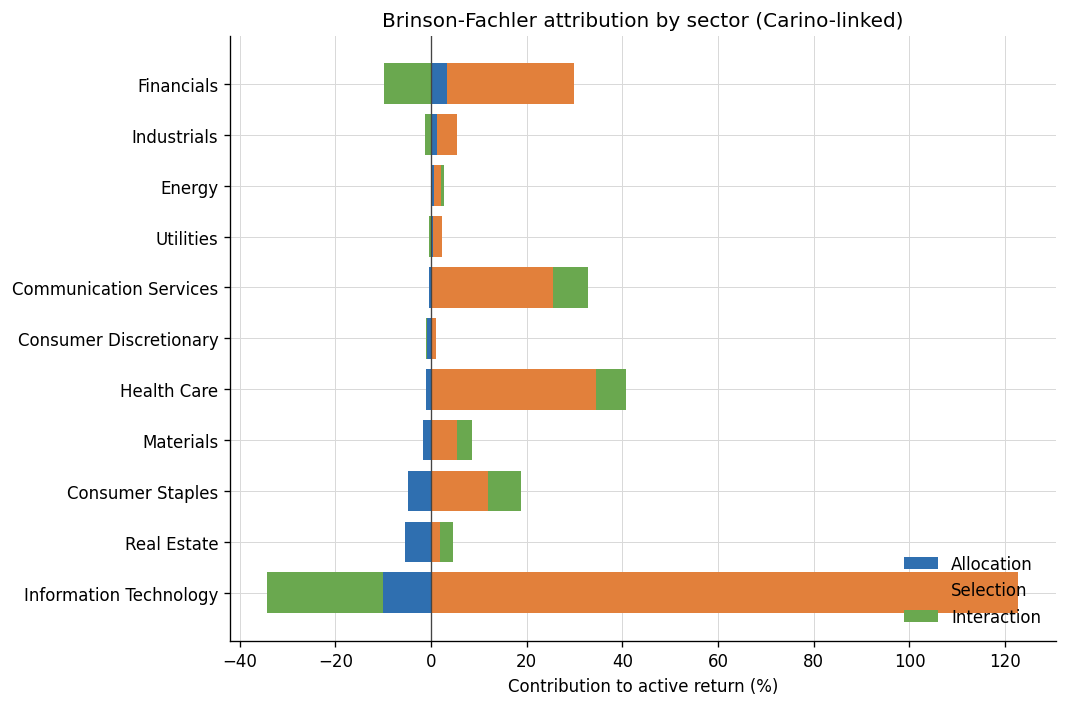

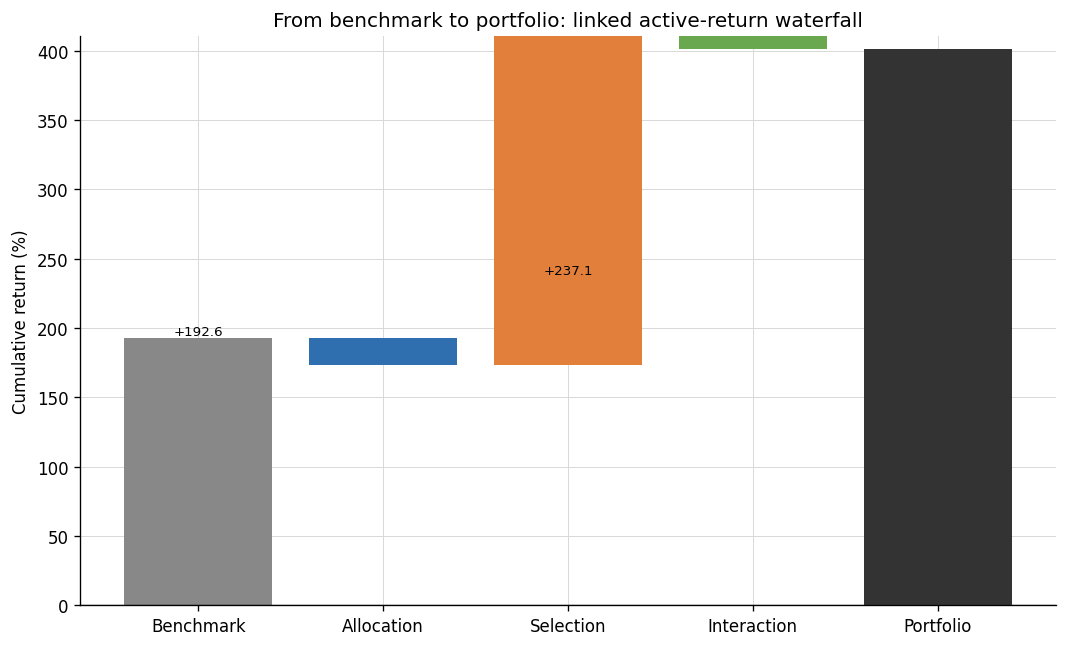

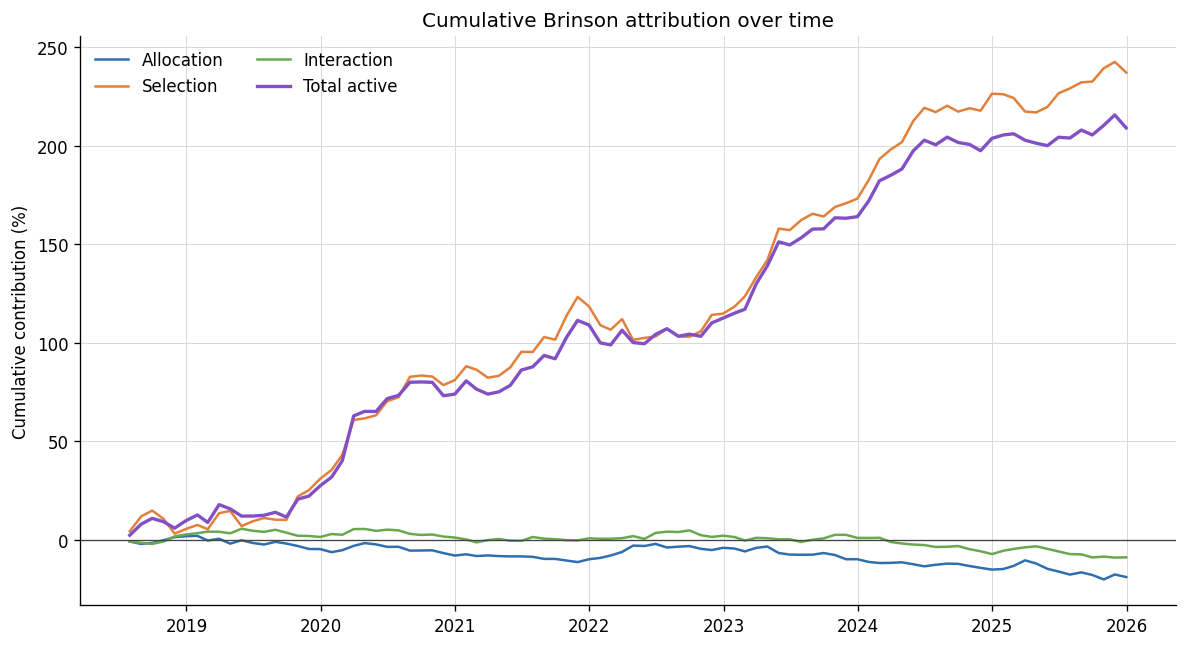

In [4]:
from attribution import plotting
import matplotlib.pyplot as plt
from IPython.display import Image, display
charts = plotting.all_brinson_charts(brinson)
for p in charts.values():
    display(Image(filename=str(p)))

## Module B — Factor attribution

In [5]:
port_excess = build_excess_return(bundle.portfolio_return, bundle.factors['RF'])
rows = {}
for name, res in regress_all_models(port_excess, bundle.factors).items():
    rows[name] = {'alpha_ann_%': res.alpha_annual*100, 'alpha_t': res.alpha_tstat,
                  'Mkt-RF': res.params.get('Mkt-RF'), 'SMB': res.params.get('SMB'),
                  'HML': res.params.get('HML'), 'MOM': res.params.get('MOM'), 'R2': res.r2}
pd.DataFrame(rows).T.round(3)

16:39:09 | INFO    | attribution.factor_model | CAPM      | n=131 lag=4 | alpha(ann)=+10.20% (t=5.90) | R2=0.910


16:39:09 | INFO    | attribution.factor_model | FF3       | n=131 lag=4 | alpha(ann)=+9.14% (t=6.53) | R2=0.939


16:39:09 | INFO    | attribution.factor_model | FF5       | n=131 lag=4 | alpha(ann)=+8.99% (t=6.43) | R2=0.941


16:39:09 | INFO    | attribution.factor_model | Carhart4  | n=131 lag=4 | alpha(ann)=+9.16% (t=6.56) | R2=0.939


16:39:09 | INFO    | attribution.factor_model | Carhart6  | n=131 lag=4 | alpha(ann)=+8.97% (t=6.38) | R2=0.941


,alpha_ann_%,alpha_t,Mkt-RF,SMB,HML,MOM,R2
CAPM,10.197,5.900,0.973,NaN,NaN,NaN,0.910
FF3,9.136,6.528,1.012,-0.191,-0.112,NaN,0.939
FF5,8.986,6.426,1.002,-0.165,-0.109,NaN,0.941
Carhart4,9.164,6.561,1.010,-0.193,-0.114,-0.007,0.939
Carhart6,8.971,6.381,1.003,-0.163,-0.108,0.003,0.941


In [6]:
res = regress(port_excess, bundle.factors, 'Carhart6')
coef = pd.DataFrame({'beta': res.params, 'NW_se': res.se, 't': res.tstats, 'p': res.pvalues})
print(f'Carhart-6: annualized alpha {res.alpha_annual*100:+.2f}% (t={res.alpha_tstat:.2f}), R2={res.r2:.3f}')
coef.round(4)

16:39:09 | INFO    | attribution.factor_model | Carhart6  | n=131 lag=4 | alpha(ann)=+8.97% (t=6.38) | R2=0.941


Carhart-6: annualized alpha +8.97% (t=6.38), R2=0.941


,beta,NW_se,t,p
alpha,0.0075,0.0012,6.3806,0.0000
Mkt-RF,1.0030,0.0281,35.6838,0.0000
SMB,-0.1634,0.0448,-3.6439,0.0003
HML,-0.1079,0.0450,-2.3988,0.0164
RMW,0.0906,0.0500,1.8123,0.0699
CMA,-0.0464,0.0625,-0.7423,0.4579
MOM,0.0033,0.0355,0.0939,0.9252


16:39:09 | INFO    | attribution.plotting | Saved chart -> /Users/rohan/Desktop/Claude Code/active-return-attribution/reports/factor_contributions.png


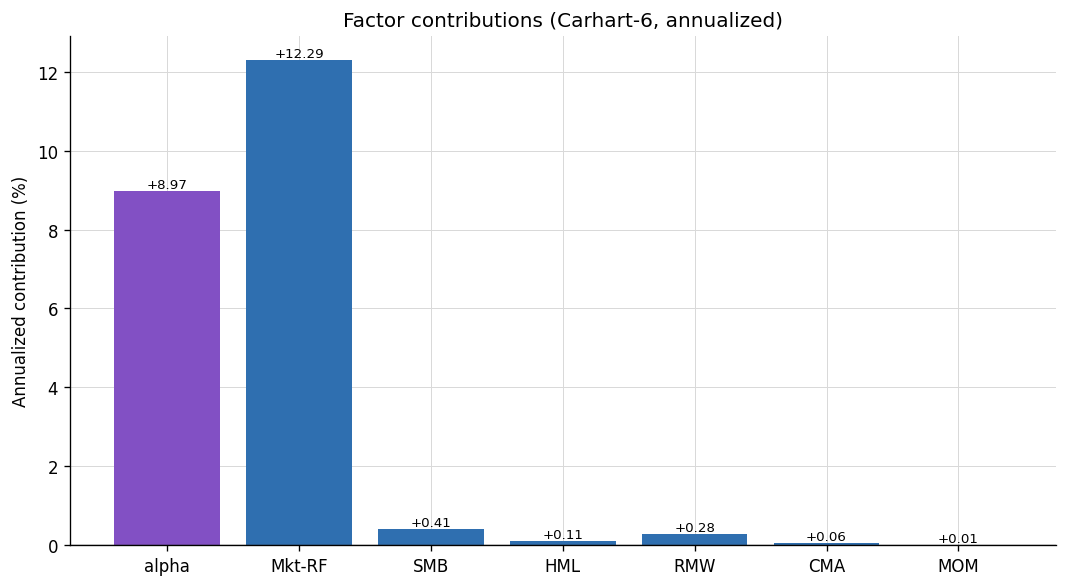

16:39:09 | INFO    | attribution.plotting | Saved chart -> /Users/rohan/Desktop/Claude Code/active-return-attribution/reports/rolling_betas.png


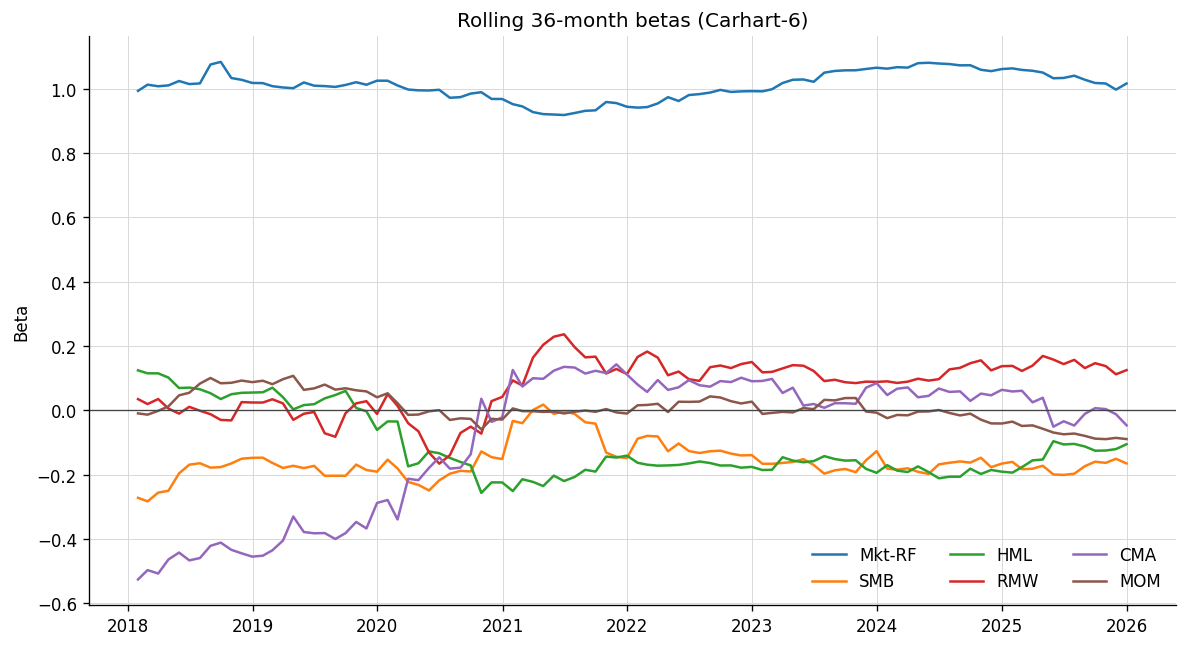

In [7]:
display(Image(filename=str(plotting.factor_contributions_bar(res, 'Factor contributions (Carhart-6, annualized)'))))
roll = rolling_betas(port_excess, bundle.factors, 'Carhart6', 36)
display(Image(filename=str(plotting.rolling_betas_line(roll, 'Rolling 36-month betas (Carhart-6)'))))

## One story, two lenses

The Brinson **selection** effect and the factor **alpha** both isolate value added beyond systematic exposures; the sector over/underweights in the Brinson **allocation** term reappear as style-factor tilts (e.g. a growth-heavy sector overweight shows up as a negative HML loading). Run `python -m attribution report` to regenerate the full combined report.